# Baseline
Ansatz:
- Übersicht der Multi-view Pig Posture Recognition Challenge
- Datenanalyse und -vorverarbeitung
- Baseline Modellierung für zukunfitge Optimierungen

In [2]:
# imports
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from tqdm import tqdm

# use cuda
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")

<jemalloc>: Unsupported system page size


## Datenanalyse

In [3]:
# Daten laden
data_dir = "/datasets/multi-view-pig-posture-recognition/"
# Train1 sind Bilder von 5 verschiedenen Kamera
train1_df = pd.read_csv(os.path.join(data_dir, "train1.csv"))
train2_df = pd.read_csv(os.path.join(data_dir, "train2.csv"))
dir_train1 = os.path.join(data_dir, "train1_images")
dir_train2 = os.path.join(data_dir, "train2_images")

test_df = pd.read_csv(os.path.join(data_dir, "test.csv"))
dir_test = os.path.join(data_dir, "test_images")

In [4]:
# Datenüberblick der trainings spalten
train1_df.head()

,row_id,image_id,width,height,bbox,class_id
0,train_pen1_orb_cam1_20250108_085204_0000,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1031.5,368.0,349.0,435.0]",0
1,train_pen1_orb_cam1_20250108_085204_0001,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1278.5,428.0,233.0,438.0]",4
2,train_pen1_orb_cam1_20250108_085204_0002,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[732.0,137.5,342.0,198.0]",1
3,train_pen1_orb_cam1_20250108_085204_0003,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[830.0,169.0,370.0,263.0]",0
4,train_pen1_orb_cam1_20250108_085204_0004,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[611.5,314.8,381.5,386.6]",3


In [5]:
# Datenüberblick der Test spalten
test_df.head()

,row_id,image_id,width,height,bbox
0,test_pen1_tur_cam1_20250920_174649_0000,pen1_tur_cam1_20250920_174649.jpg,1280,720,"[432.0,291.0,306.0,394.0]"
1,test_pen1_tur_cam1_20250920_174649_0001,pen1_tur_cam1_20250920_174649.jpg,1280,720,"[237.0,254.0,246.0,402.0]"
2,test_pen1_tur_cam1_20250920_174649_0002,pen1_tur_cam1_20250920_174649.jpg,1280,720,"[742.5,387.0,235.0,258.0]"
3,test_pen1_tur_cam1_20250920_174649_0003,pen1_tur_cam1_20250920_174649.jpg,1280,720,"[357.5,263.0,234.0,374.0]"
4,test_pen1_tur_cam1_20250920_174649_0004,pen1_tur_cam1_20250920_174649.jpg,1280,720,"[342.5,2.0,356.0,157.0]"


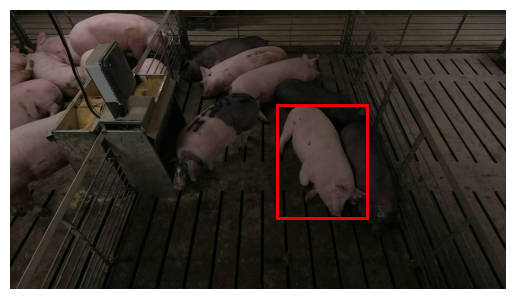

In [6]:
def show_image_with_bbox(image_path, bbox):
    image = Image.open(image_path)
    plt.imshow(image)
    x, y, width, height = bbox
    plt.gca().add_patch(
        plt.Rectangle(
            (x, y), width, height, edgecolor="red", facecolor="none", linewidth=2
        )
    )
    plt.axis("off")
    plt.show()


def parse_bbox(bbox_str):
    if isinstance(bbox_str, str):
        return [float(x) for x in bbox_str.replace("[", "").replace("]", "").split(",")]
    return bbox_str


row = train1_df.iloc[0]
bbox_data = parse_bbox(row["bbox"])
img_path = os.path.join(dir_train1, row["image_id"])
show_image_with_bbox(img_path, bbox_data)

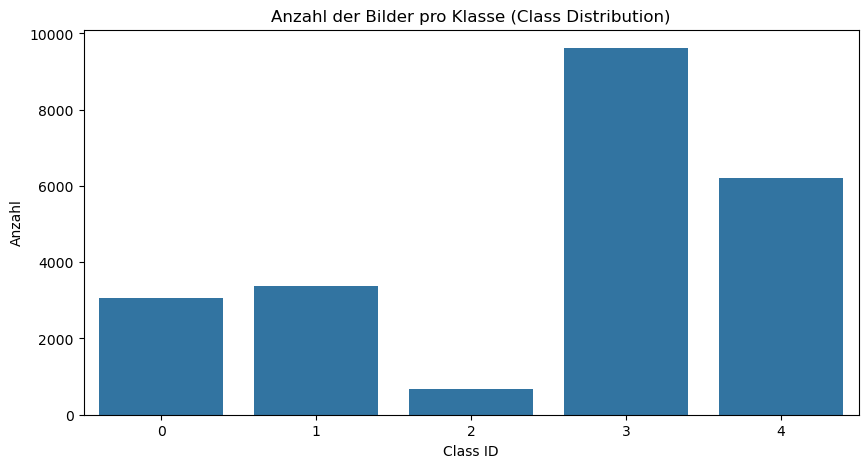

In [7]:
class_counts = train1_df["class_id"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Anzahl der Bilder pro Klasse (Class Distribution)")
plt.xlabel("Class ID")
plt.ylabel("Anzahl")
plt.show()

Text(0.5, 1.0, 'Relative Box-Größe (Fläche)')

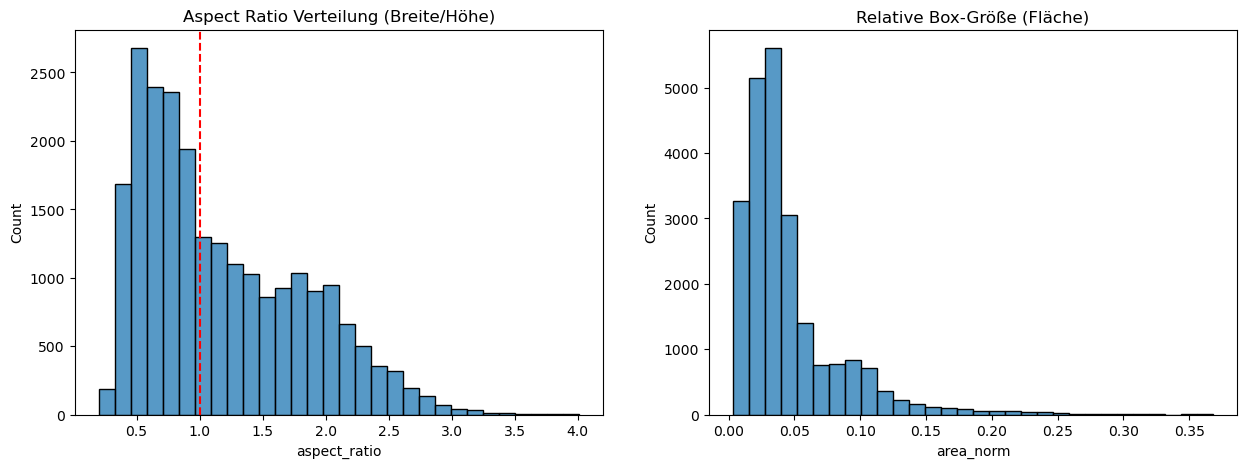

In [8]:
def parse_bbox_safe(x):
    if isinstance(x, str):
        # Klammern weg, splitten, zu Floats machen
        return [float(i) for i in x.replace("[", "").replace("]", "").split(",")]
    return x  # Falls es schon eine Liste ist, einfach zurückgeben


# 2. KONVERTIERUNG: Wir wenden das auf die ganze Spalte an
# Das überschreibt die Strings mit echten Listen [x, y, w, h]
train1_df["bbox"] = train1_df["bbox"].apply(parse_bbox_safe)

# 3. DATAFRAME ERSTELLEN
# Jetzt funktioniert tolist(), weil es eine Liste von Listen erzeugt
bbox_data = train1_df["bbox"].tolist()
bbox_stats = pd.DataFrame(bbox_data, columns=["x", "y", "w", "h"])

# --- JETZT LÄUFT IHRE EDA ---

# Aspekt-Ratio (Breite / Höhe)
bbox_stats["aspect_ratio"] = bbox_stats["w"] / bbox_stats["h"]
# Fläche relativ zum Bild (normiert auf 1920x1080)
bbox_stats["area_norm"] = (bbox_stats["w"] * bbox_stats["h"]) / (1920 * 1080)

# Visualisierung
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Wie "langgezogen" sind die Boxen?
sns.histplot(bbox_stats["aspect_ratio"], bins=30, ax=ax[0])
ax[0].set_title("Aspect Ratio Verteilung (Breite/Höhe)")
ax[0].axvline(1, color="red", linestyle="--")  # Referenzlinie Quadrat

# Plot 2: Wie groß sind die Schweine im Bild?
sns.histplot(bbox_stats["area_norm"], bins=30, ax=ax[1])
ax[1].set_title("Relative Box-Größe (Fläche)")

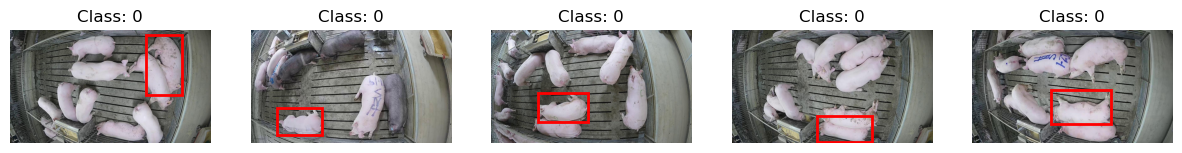

In [9]:
def show_grid_per_class(class_id, num_images=5):
    # Filtern nach Klasse
    subset = train1_df[train1_df["class_id"] == class_id].sample(
        n=num_images, replace=True
    )

    plt.figure(figsize=(15, 3))
    for i, (_, row) in enumerate(subset.iterrows()):
        img_path = os.path.join(dir_train1, row["image_id"])
        bbox = parse_bbox(row["bbox"])  # Unsere Funktion von vorhin

        plt.subplot(1, num_images, i + 1)
        image = Image.open(img_path)
        plt.imshow(image)

        x, y, w, h = bbox
        plt.gca().add_patch(
            plt.Rectangle((x, y), w, h, edgecolor="red", facecolor="none", linewidth=2)
        )
        plt.axis("off")
        plt.title(f"Class: {class_id}")
    plt.show()


# Beispiel: Zeige 5 Bilder von Klasse 0
show_grid_per_class(0)

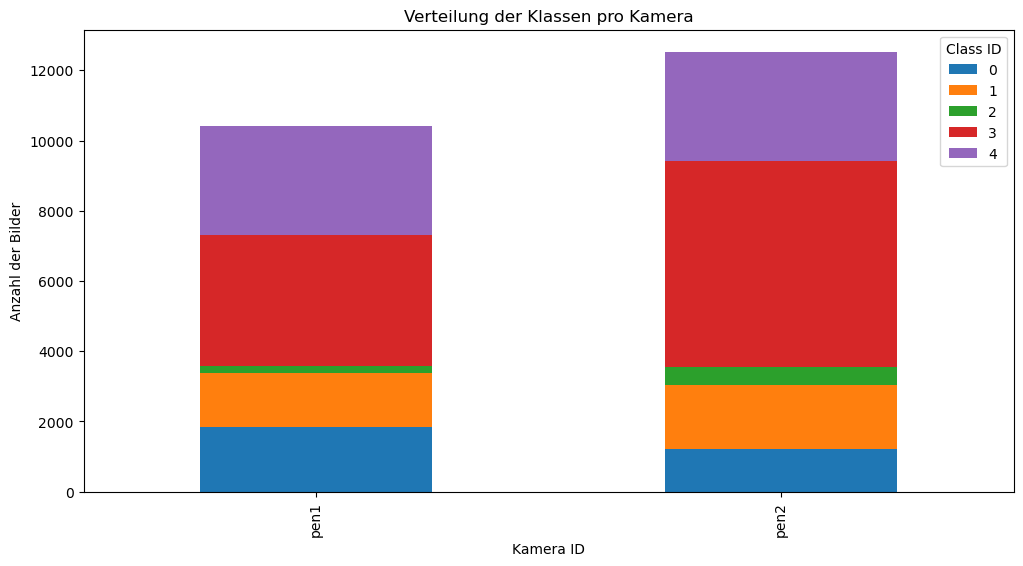

In [10]:
# weitere analyse: Verteilung der Klassen über die verschiedenen Kameras
train1_df["camera_id"] = train1_df["image_id"].apply(
    lambda x: x.split("_")[0]
)  # Extrahieren der Kamera-ID
camera_class_counts = (
    train1_df.groupby(["camera_id", "class_id"]).size().unstack(fill_value=0)
)
plt.figure(figsize=(12, 6))
camera_class_counts.plot(kind="bar", stacked=True, ax=plt.gca())
plt.title("Verteilung der Klassen pro Kamera")
plt.xlabel("Kamera ID")
plt.ylabel("Anzahl der Bilder")
plt.legend(title="Class ID")

# First Model


In [11]:
# create first NN model with resnet50 as backbone
class PigPostureDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["image_id"])
        image = Image.open(img_path).convert("RGB")
        label = row["class_id"]

        if self.transform:
            image = self.transform(image)

        return image, label

In [12]:
# define transformations
transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

In [28]:
# create dataset and dataloader train with 100 images for faster training and testing of the pipeline
train1_df = train1_df.sample(n=500, random_state=42).reset_index(drop=True)
train_dataset = PigPostureDataset(train1_df, dir_train1, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

In [29]:
# define model
class PigPostureModel(nn.Module):
    def __init__(self, num_classes=5):
        super(PigPostureModel, self).__init__()
        self.backbone = models.resnet50(pretrained=True)
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

In [30]:
# train model, show tqdm progress bar and print loss every epoch and visualize the training progress with a line plot of the loss over epochs (function)
def train_model(model, dataloader, criterion, optimizer, num_epochs=5):
    model.to(device)
    model.train()
    loss_history = []

    for epoch in range(num_epochs):
        running_loss = 0.0
        for images, labels in tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(dataloader.dataset)
        loss_history.append(epoch_loss)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

    # Plot loss history
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, num_epochs + 1), loss_history, marker="o")
    plt.title("Training Loss über Epochen")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.xticks(range(1, num_epochs + 1))
    plt.grid()
    plt.show()

Epoch 1/3: 100%|████████████████████████████████| 32/32 [00:20<00:00,  1.53it/s]


Epoch 1/3, Loss: 2.2778


Epoch 2/3: 100%|████████████████████████████████| 32/32 [00:20<00:00,  1.57it/s]


Epoch 2/3, Loss: 1.3813


Epoch 3/3: 100%|████████████████████████████████| 32/32 [00:20<00:00,  1.58it/s]

Epoch 3/3, Loss: 1.4075


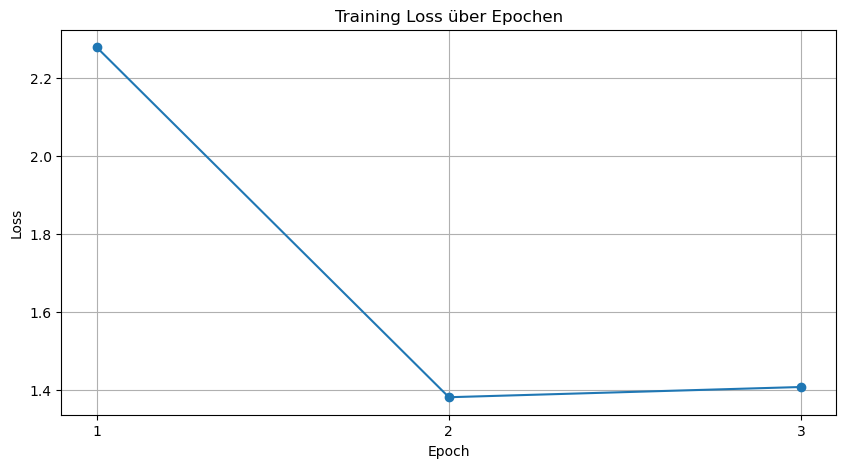

In [31]:
# initialize model, criterion and optimizer
model = PigPostureModel(num_classes=5)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
# train model
train_model(model, train_loader, criterion, optimizer, num_epochs=3)

Accuracy: 0.4280


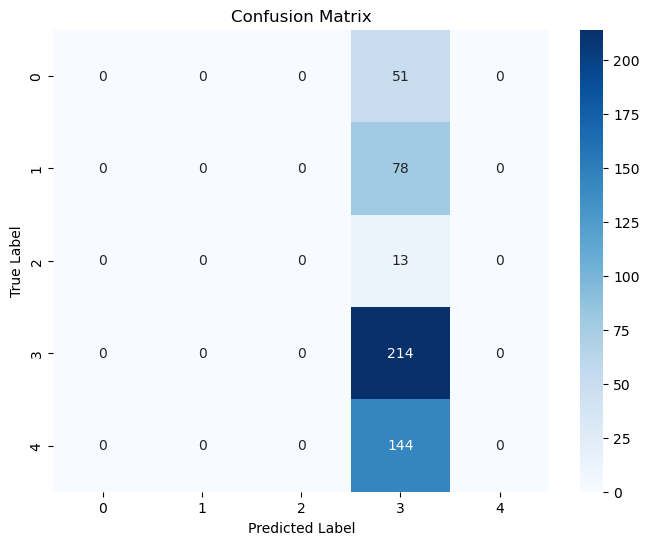

In [32]:
# evaluate model on a batch of test data and show the accuracy and a confusion matrix
def evaluate_model(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    accuracy = correct / total
    print(f"Accuracy: {accuracy:.4f}")

    # Confusion Matrix
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


# evaluate model on train data for testing the pipeline
evaluate_model(model, train_loader)